In [1]:
# ==========================================
# CELL 1: SETUP + DATA LOADING + REPRODUCIBILITY
# ==========================================
import os
import random
import numpy as np
import tensorflow as tf
import glob
import cv2
import time
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from skimage.metrics import structural_similarity
from scipy.stats import wilcoxon
import warnings
warnings.filterwarnings('ignore')

# --- Seeds ---
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# --- Mixed Precision ---
tf.keras.mixed_precision.set_global_policy('mixed_float16')

IMG_SIZE = 256
NOISE_LEVELS = [0.1, 0.2, 0.3]
BATCH_SIZE = 8

# --- Paths ---
BASE_PATH = '/kaggle/input/datasets/haris2705/harisc/BraTsss/dataset'
TRAIN_DIR = os.path.join(BASE_PATH, 'train')
VALID_DIR = os.path.join(BASE_PATH, 'valid')

def load_images_from_folder(folder_path):
    image_paths = []
    for ext in ['*.jpg', '*.jpeg', '*.JPG', '*.JPEG']:
        image_paths.extend(glob.glob(os.path.join(folder_path, ext)))
    image_paths = list(set(image_paths))
    print(f"📂 Found {len(image_paths)} images in {folder_path}")
    
    images = []
    for path in image_paths:
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img = img / 255.0
        images.append(img)
    
    if len(images) == 0:
        raise ValueError(f"No images loaded from {folder_path}")
    return np.array(images).reshape(-1, IMG_SIZE, IMG_SIZE, 1)

print("="*60)
print("📊 LOADING DATASET")
print("="*60)

train_full = load_images_from_folder(TRAIN_DIR)
valid_full = load_images_from_folder(VALID_DIR)

X_train, X_val = train_test_split(train_full, test_size=0.2, random_state=SEED)
X_test = valid_full

print(f"Training:   {X_train.shape[0]} images")
print(f"Validation: {X_val.shape[0]} images")
print(f"Test:       {X_test.shape[0]} images")

# --- Noise Functions ---
def add_spn(image, density):
    noisy = image.copy()
    mask = np.random.random(image.shape)
    noisy[mask < density/2] = 1.0
    noisy[mask > 1 - density/2] = 0.0
    return noisy

def add_gaussian_noise(image, sigma=0.1):
    return np.clip(image + np.random.normal(0, sigma, image.shape), 0, 1)

def add_rician_noise(image, snr_db=15):
    signal_power = np.mean(image**2)
    snr_linear = 10**(snr_db / 10.0)
    noise_std = np.sqrt(signal_power / snr_linear)
    noisy = np.sqrt((image + np.random.normal(0, noise_std, image.shape))**2 +
                    (np.random.normal(0, noise_std, image.shape))**2)
    noisy = (noisy - noisy.min()) / (noisy.max() - noisy.min() + 1e-8)
    return np.clip(noisy, 0, 1)

def add_poisson_noise(image):
    return np.clip(np.random.poisson(image * 255.0) / 255.0, 0, 1)

# Generate noisy data
train_noisy_dict, val_noisy_dict, test_noisy_dict = {}, {}, {}

for n in NOISE_LEVELS:
    key = f'spn_{int(n*100)}'
    train_noisy_dict[key] = np.array([add_spn(img, n) for img in X_train])
    val_noisy_dict[key]   = np.array([add_spn(img, n) for img in X_val])
    test_noisy_dict[key]  = np.array([add_spn(img, n) for img in X_test])

for ntype, func in [('gaussian', add_gaussian_noise),
                    ('rician', add_rician_noise),
                    ('poisson', add_poisson_noise)]:
    test_noisy_dict[ntype] = np.array([func(img) for img in X_test])

print("\n✅ All noisy datasets generated!")

# Reproducibility print
print("\n" + "="*60)
print("🔒 REPRODUCIBILITY SETTINGS")
print("="*60)
print(f"SEED                 : {SEED}")
print(f"Image Size           : {IMG_SIZE}x{IMG_SIZE}")
print(f"Batch Size           : {BATCH_SIZE}")
print(f"Optimizer            : Adam(lr=1e-4)")
print(f"Mixed Precision      : {tf.keras.mixed_precision.global_policy().name}")
print(f"TensorFlow           : {tf.__version__}")
print(f"GPU Available        : {len(tf.config.list_physical_devices('GPU'))}")
print("="*60)

📊 LOADING DATASET
📂 Found 2803 images in /kaggle/input/datasets/haris2705/harisc/BraTsss/dataset/train
📂 Found 203 images in /kaggle/input/datasets/haris2705/harisc/BraTsss/dataset/valid
Training:   2242 images
Validation: 561 images
Test:       203 images

✅ All noisy datasets generated!

🔒 REPRODUCIBILITY SETTINGS
SEED                 : 42
Image Size           : 256x256
Batch Size           : 8
Optimizer            : Adam(lr=1e-4)
Mixed Precision      : mixed_float16
TensorFlow           : 2.20.0
GPU Available        : 1


In [2]:
# ==========================================
# CELL 2: MODEL ARCHITECTURES
# ==========================================
from tensorflow.keras import layers, Model, Input

def residual_block(x, filters):
    shortcut = x
    x = layers.Conv2D(filters, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Conv2D(filters, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.add([x, shortcut])
    x = layers.LeakyReLU(0.2)(x)
    return x

def build_rae(use_skip=True, use_res=True):
    inp = Input(shape=(IMG_SIZE, IMG_SIZE, 1))
    
    e1 = layers.Conv2D(64, 3, padding='same')(inp)
    e1 = layers.BatchNormalization()(e1)
    e1 = layers.LeakyReLU(0.2)(e1)
    if use_res: e1 = residual_block(e1, 64)
    p1 = layers.MaxPooling2D()(e1)
    
    e2 = layers.Conv2D(128, 3, padding='same')(p1)
    e2 = layers.BatchNormalization()(e2)
    e2 = layers.LeakyReLU(0.2)(e2)
    if use_res: e2 = residual_block(e2, 128)
    p2 = layers.MaxPooling2D()(e2)
    
    e3 = layers.Conv2D(256, 3, padding='same')(p2)
    e3 = layers.BatchNormalization()(e3)
    e3 = layers.LeakyReLU(0.2)(e3)
    if use_res: e3 = residual_block(e3, 256)
    p3 = layers.MaxPooling2D()(e3)
    
    e4 = layers.Conv2D(256, 3, padding='same')(p3)
    e4 = layers.BatchNormalization()(e4)
    e4 = layers.LeakyReLU(0.2)(e4)
    if use_res: e4 = residual_block(e4, 256)
    p4 = layers.MaxPooling2D()(e4)
    
    b = layers.Conv2D(512, 3, padding='same')(p4)
    b = layers.BatchNormalization()(b)
    b = layers.LeakyReLU(0.2)(b)
    if use_res: b = residual_block(b, 512)
    
    d1 = layers.UpSampling2D()(b)
    d1 = layers.Conv2D(256, 3, padding='same')(d1)
    d1 = layers.BatchNormalization()(d1)
    d1 = layers.LeakyReLU(0.2)(d1)
    if use_skip: d1 = layers.concatenate([d1, e4])
    
    d2 = layers.UpSampling2D()(d1)
    d2 = layers.Conv2D(128, 3, padding='same')(d2)
    d2 = layers.BatchNormalization()(d2)
    d2 = layers.LeakyReLU(0.2)(d2)
    if use_skip: d2 = layers.concatenate([d2, e3])
    
    d3 = layers.UpSampling2D()(d2)
    d3 = layers.Conv2D(64, 3, padding='same')(d3)
    d3 = layers.BatchNormalization()(d3)
    d3 = layers.LeakyReLU(0.2)(d3)
    if use_skip: d3 = layers.concatenate([d3, e2])
    
    d4 = layers.UpSampling2D()(d3)
    d4 = layers.Conv2D(64, 3, padding='same')(d4)
    d4 = layers.BatchNormalization()(d4)
    d4 = layers.LeakyReLU(0.2)(d4)
    if use_skip: d4 = layers.concatenate([d4, e1])
    
    out = layers.Conv2D(1, 1, activation='sigmoid')(d4)
    return Model(inp, out, name="RAE")

def build_dncnn():
    inp = Input(shape=(IMG_SIZE, IMG_SIZE, 1))
    x = layers.Conv2D(64, 3, padding='same', activation='relu')(inp)
    for _ in range(8):
        x = layers.Conv2D(64, 3, padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation('relu')(x)
    x = layers.Conv2D(1, 3, padding='same')(x)
    return Model(inp, layers.Add()([inp, x]), name="DnCNN")

def build_unet():
    inputs = Input(shape=(IMG_SIZE, IMG_SIZE, 1))
    c1 = layers.Conv2D(64, 3, activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(64, 3, activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D()(c1)
    
    c2 = layers.Conv2D(128, 3, activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(128, 3, activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D()(c2)
    
    c3 = layers.Conv2D(256, 3, activation='relu', padding='same')(p2)
    c3 = layers.Conv2D(256, 3, activation='relu', padding='same')(c3)
    p3 = layers.MaxPooling2D()(c3)
    
    c4 = layers.Conv2D(512, 3, activation='relu', padding='same')(p3)
    c4 = layers.Conv2D(512, 3, activation='relu', padding='same')(c4)
    
    u5 = layers.UpSampling2D()(c4)
    u5 = layers.concatenate([u5, c3])
    c5 = layers.Conv2D(256, 3, activation='relu', padding='same')(u5)
    c5 = layers.Conv2D(256, 3, activation='relu', padding='same')(c5)
    
    u6 = layers.UpSampling2D()(c5)
    u6 = layers.concatenate([u6, c2])
    c6 = layers.Conv2D(128, 3, activation='relu', padding='same')(u6)
    c6 = layers.Conv2D(128, 3, activation='relu', padding='same')(c6)
    
    u7 = layers.UpSampling2D()(c6)
    u7 = layers.concatenate([u7, c1])
    c7 = layers.Conv2D(64, 3, activation='relu', padding='same')(u7)
    c7 = layers.Conv2D(64, 3, activation='relu', padding='same')(c7)
    
    return Model(inputs, layers.Conv2D(1, 1, activation='sigmoid')(c7), name="UNet")

def transformer_block(x, num_heads=4, key_dim=64, ff_dim=256):
    attn = layers.MultiHeadAttention(num_heads=num_heads, key_dim=key_dim)(x, x)
    attn = layers.Dropout(0.1)(attn)
    out1 = layers.LayerNormalization(epsilon=1e-6)(x + attn)
    ffn = layers.Dense(ff_dim, activation='relu')(out1)
    ffn = layers.Dense(x.shape[-1])(ffn)
    ffn = layers.Dropout(0.1)(ffn)
    return layers.LayerNormalization(epsilon=1e-6)(out1 + ffn)

def build_transformer_unet():
    inputs = Input(shape=(IMG_SIZE, IMG_SIZE, 1))
    
    c1 = layers.Conv2D(64, 3, activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(64, 3, activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D()(c1)
    
    c2 = layers.Conv2D(128, 3, activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(128, 3, activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D()(c2)
    
    c3 = layers.Conv2D(256, 3, activation='relu', padding='same')(p2)
    c3 = layers.Conv2D(256, 3, activation='relu', padding='same')(c3)
    p3 = layers.MaxPooling2D()(c3)
    
    b = layers.Conv2D(512, 3, activation='relu', padding='same')(p3)
    b = layers.Reshape((32*32, 512))(b)
    b = transformer_block(b)
    b = transformer_block(b)
    b = layers.Reshape((32, 32, 512))(b)
    
    u4 = layers.UpSampling2D()(b)
    u4 = layers.concatenate([u4, c3])
    c4 = layers.Conv2D(256, 3, activation='relu', padding='same')(u4)
    c4 = layers.Conv2D(256, 3, activation='relu', padding='same')(c4)
    
    u5 = layers.UpSampling2D()(c4)
    u5 = layers.concatenate([u5, c2])
    c5 = layers.Conv2D(128, 3, activation='relu', padding='same')(u5)
    c5 = layers.Conv2D(128, 3, activation='relu', padding='same')(c5)
    
    u6 = layers.UpSampling2D()(c5)
    u6 = layers.concatenate([u6, c1])
    c6 = layers.Conv2D(64, 3, activation='relu', padding='same')(u6)
    c6 = layers.Conv2D(64, 3, activation='relu', padding='same')(c6)
    
    return Model(inputs, layers.Conv2D(1, 1, activation='sigmoid')(c6), name="Transformer_UNet")

print("✅ All models defined: RAE | DnCNN | U-Net | Transformer-UNet")

✅ All models defined: RAE | DnCNN | U-Net | Transformer-UNet


In [3]:
# ==========================================
# CELL 3: LOSS + EVALUATION HELPERS
# ==========================================
def tukey_loss(y_true, y_pred, c=4.685):
    r = tf.cast(y_true - y_pred, tf.float32)
    abs_r = tf.abs(r)
    condition = tf.less_equal(abs_r, c)
    loss_true = (c**2 / 6.0) * (1 - tf.pow(1 - tf.pow(r / c, 2), 3))
    loss_false = tf.constant(c**2 / 6.0, dtype=tf.float32)
    return tf.where(condition, loss_true, loss_false)

def mse_loss(y_true, y_pred):
    return tf.reduce_mean(tf.square(y_true - y_pred))

def compile_model(model, loss_fn):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-4, beta_1=0.9, beta_2=0.999, epsilon=1e-8),
        loss=loss_fn,
        metrics=['mae']
    )
    return model

def compute_metrics(clean, denoised):
    clean_f = clean.astype(np.float64)
    denoised_f = denoised.astype(np.float64)
    mse = np.mean((clean_f - denoised_f)**2)
    psnr = 20 * np.log10(1.0 / (np.sqrt(mse) + 1e-8))
    ssim = structural_similarity(clean_f.squeeze(), denoised_f.squeeze(), data_range=1.0)
    return psnr, ssim

def evaluate_model(model, noisy_set):
    preds = model.predict(noisy_set, verbose=0)
    scores = [compute_metrics(X_test[i], preds[i]) for i in range(len(X_test))]
    scores = np.array(scores)
    return scores.mean(axis=0), scores.std(axis=0)

def get_per_image_psnr(model, noisy_set):
    preds = model.predict(noisy_set, verbose=0)
    return np.array([compute_metrics(X_test[i], preds[i])[0] for i in range(len(X_test))])

def statistical_comparison(scores_a, scores_b, name_a, name_b):
    try:
        _, p = wilcoxon(scores_a, scores_b)
        diff = scores_a.mean() - scores_b.mean()
        p_str = "p < 0.001" if p < 0.001 else f"p = {p:.4f}"
        print(f"  {name_a} vs {name_b}: Δ = {diff:+.2f} dB | {p_str}")
    except Exception as e:
        print(f"  Test failed: {e}")

print("✅ Loss functions and helpers ready.")

✅ Loss functions and helpers ready.


🚀 Training Proposed RAE (30% SPN) with Tukey loss...


I0000 00:00:1786539882.267958      59 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Epoch 1/30


I0000 00:00:1786539952.747848     131 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


281/281 ━━━━━━━━━━━━━━━━━━━━ 164s 346ms/step - loss: 0.0073 - mae: 0.0782 - val_loss: 0.0312 - val_mae: 0.2142 - learning_rate: 1.0000e-04
Epoch 2/30
281/281 ━━━━━━━━━━━━━━━━━━━━ 51s 181ms/step - loss: 0.0038 - mae: 0.0547 - val_loss: 0.0095 - val_mae: 0.1129 - learning_rate: 1.0000e-04
Epoch 3/30
281/281 ━━━━━━━━━━━━━━━━━━━━ 51s 181ms/step - loss: 0.0029 - mae: 0.0468 - val_loss: 0.0028 - val_mae: 0.0452 - learning_rate: 1.0000e-04
Epoch 4/30
281/281 ━━━━━━━━━━━━━━━━━━━━ 51s 181ms/step - loss: 0.0023 - mae: 0.0412 - val_loss: 0.0023 - val_mae: 0.0398 - learning_rate: 1.0000e-04
Epoch 5/30
281/281 ━━━━━━━━━━━━━━━━━━━━ 51s 181ms/step - loss: 0.0020 - mae: 0.0373 - val_loss: 0.0020 - val_mae: 0.0359 - learning_rate: 1.0000e-04
Epoch 6/30
281/281 ━━━━━━━━━━━━━━━━━━━━ 51s 181ms/step - loss: 0.0018 - mae: 0.0346 - val_loss: 0.0016 - val_mae: 0.0325 - learning_rate: 1.0000e-04
Epoch 7/30
281/281 ━━━━━━━━━━━━━━━━━━━━ 51s 181ms/step - loss: 0.0016 - mae: 0.0325 - val_loss: 0.0015 - val_mae: 0.

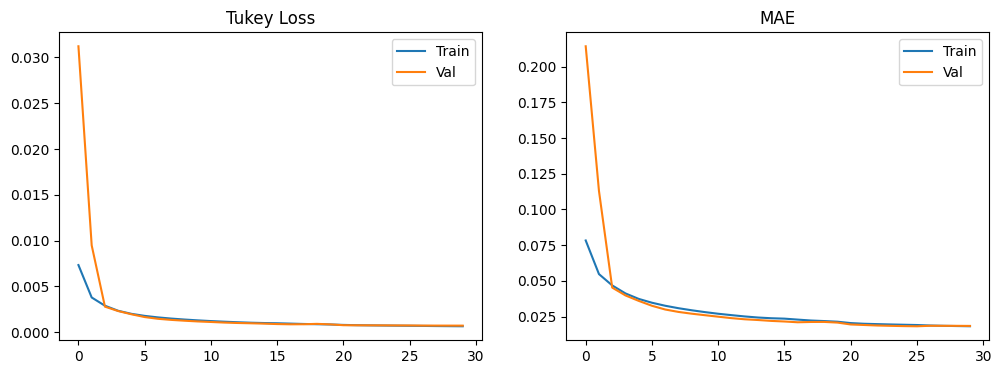

✅ Main RAE trained.


In [4]:
# ==========================================
# CELL 4: TRAIN MAIN RAE (30% SPN)
# ==========================================
os.makedirs('/kaggle/working/0601', exist_ok=True)

callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1),
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ModelCheckpoint('/kaggle/working/0601/best_rae_model.keras',
                                       save_best_only=True, monitor='val_loss')
]

print("🚀 Training Proposed RAE (30% SPN) with Tukey loss...")
model_rae_30 = build_rae(use_skip=True, use_res=True)
model_rae_30 = compile_model(model_rae_30, tukey_loss)

history = model_rae_30.fit(
    train_noisy_dict['spn_30'], X_train,
    validation_data=(val_noisy_dict['spn_30'], X_val),
    epochs=30,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title('Tukey Loss')
plt.legend()
plt.subplot(1,2,2)
plt.plot(history.history['mae'], label='Train')
plt.plot(history.history['val_mae'], label='Val')
plt.title('MAE')
plt.legend()
plt.savefig('/kaggle/working/0601/training_curves_rae_30.png', dpi=300)
plt.show()

print("✅ Main RAE trained.")

In [5]:
# ==========================================
# CELL 5: ABLATION STUDIES
# ==========================================
print("\n" + "="*60)
print("🔬 ABLATION 1: Architecture Components")
print("="*60)

def quick_train(params, loss_fn, name, epochs=12):
    print(f"⏳ {name}")
    model = build_rae(**params)
    model = compile_model(model, loss_fn)
    model.fit(train_noisy_dict['spn_30'], X_train,
              validation_data=(val_noisy_dict['spn_30'], X_val),
              epochs=epochs, batch_size=BATCH_SIZE, verbose=0,
              callbacks=[tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)])
    return model

ablation_arch = {
    'No Skip Connections': {'use_skip': False, 'use_res': True},
    'No Residual Blocks':  {'use_skip': True,  'use_res': False},
    'Tukey → MSE':         {'use_skip': True,  'use_res': True},
    'Standard AE + MSE':   {'use_skip': False, 'use_res': False}
}

ablated_models = {}
for name, params in ablation_arch.items():
    loss_fn = mse_loss if 'MSE' in name else tukey_loss
    ablated_models[name] = quick_train(params, loss_fn, name)

# Quantitative results
print("\nArchitecture Ablation Results (30% SPN):")
ablation_results = []

mean, std = evaluate_model(model_rae_30, test_noisy_dict['spn_30'])
ablation_results.append({'Variant': 'Proposed RAE (Full)', 
                         'PSNR': f"{mean[0]:.2f}±{std[0]:.2f}", 
                         'SSIM': f"{mean[1]:.3f}±{std[1]:.3f}"})

for name, model in ablated_models.items():
    mean, std = evaluate_model(model, test_noisy_dict['spn_30'])
    ablation_results.append({'Variant': name, 
                             'PSNR': f"{mean[0]:.2f}±{std[0]:.2f}", 
                             'SSIM': f"{mean[1]:.3f}±{std[1]:.3f}"})

df_ab = pd.DataFrame(ablation_results)
print(df_ab.to_string(index=False))
df_ab.to_csv('/kaggle/working/0601/ablation_architecture.csv', index=False)

# ----- Tukey c Ablation -----
print("\n" + "="*60)
print("🔬 ABLATION 2: Tukey Constant c")
print("="*60)

c_results = []
for c in [3.0, 4.685, 6.0]:
    print(f"⏳ Training with c = {c}")
    model = build_rae(True, True)
    model = compile_model(model, lambda y,p: tukey_loss(y, p, c=c))
    model.fit(train_noisy_dict['spn_30'], X_train,
              validation_data=(val_noisy_dict['spn_30'], X_val),
              epochs=12, batch_size=BATCH_SIZE, verbose=0,
              callbacks=[tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)])
    
    mean, std = evaluate_model(model, test_noisy_dict['spn_30'])
    c_results.append({'c': c, 'PSNR': f"{mean[0]:.2f}±{std[0]:.2f}", 'SSIM': f"{mean[1]:.3f}±{std[1]:.3f}"})
    print(f"   → PSNR: {mean[0]:.2f}")

df_c = pd.DataFrame(c_results)
print(df_c.to_string(index=False))
df_c.to_csv('/kaggle/working/0601/ablation_tukey_c.csv', index=False)
print("\n✅ All ablations completed.")


🔬 ABLATION 1: Architecture Components
⏳ No Skip Connections
⏳ No Residual Blocks
⏳ Tukey → MSE
⏳ Standard AE + MSE

Architecture Ablation Results (30% SPN):


2026-08-12 14:02:52.636202: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-12 14:02:52.872076: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-12 14:02:53.744428: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-12 14:02:54.003133: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-12 14:02:56.050896: E external/local_xla/xla/stream_

            Variant       PSNR        SSIM
Proposed RAE (Full) 33.27±2.18 0.924±0.014
No Skip Connections 24.36±2.21 0.721±0.056
 No Residual Blocks 27.81±1.83 0.813±0.037
        Tukey → MSE 30.22±1.83 0.881±0.032
  Standard AE + MSE 23.13±2.04 0.632±0.064

🔬 ABLATION 2: Tukey Constant c
⏳ Training with c = 3.0
   → PSNR: 30.67
⏳ Training with c = 4.685
   → PSNR: 30.22
⏳ Training with c = 6.0
   → PSNR: 30.33
    c       PSNR        SSIM
3.000 30.67±1.89 0.884±0.032
4.685 30.22±1.85 0.882±0.032
6.000 30.33±1.86 0.868±0.025

✅ All ablations completed.


In [7]:
# ==========================================
# CELL 6: TRAIN BASELINES
# ==========================================
all_trained_models = {
    'spn_10': {},
    'spn_20': {},
    'spn_30': {'Proposed RAE (Tukey)': model_rae_30}
}

def train_one(builder, loss_fn, key, name, epochs=15):
    print(f"⏳ {name} on {key}")
    model = builder()
    model = compile_model(model, loss_fn)
    model.fit(train_noisy_dict[key], X_train,
              validation_data=(val_noisy_dict[key], X_val),
              epochs=epochs, batch_size=BATCH_SIZE, verbose=0,
              callbacks=[tf.keras.callbacks.EarlyStopping(patience=6, restore_best_weights=True)])
    return model

for noise in [0.1, 0.2, 0.3]:
    key = f'spn_{int(noise*100)}'
    print(f"\n===== {key} =====")
    
    if noise != 0.3:
        rae = build_rae(True, True)
        rae = compile_model(rae, tukey_loss)
        rae.fit(train_noisy_dict[key], X_train,
                validation_data=(val_noisy_dict[key], X_val),
                epochs=15, batch_size=BATCH_SIZE, verbose=0,
                callbacks=[tf.keras.callbacks.EarlyStopping(patience=6, restore_best_weights=True)])
        all_trained_models[key]['Proposed RAE (Tukey)'] = rae
    
    all_trained_models[key]['DnCNN'] = train_one(build_dncnn, mse_loss, key, 'DnCNN')
    all_trained_models[key]['U-Net'] = train_one(build_unet, mse_loss, key, 'U-Net')
    all_trained_models[key]['Transformer-UNet'] = train_one(build_transformer_unet, mse_loss, key, 'Transformer-UNet')

print("\n✅ All baselines trained.")



===== spn_10 =====
⏳ DnCNN on spn_10
⏳ U-Net on spn_10
⏳ Transformer-UNet on spn_10

===== spn_20 =====
⏳ DnCNN on spn_20
⏳ U-Net on spn_20
⏳ Transformer-UNet on spn_20

===== spn_30 =====
⏳ DnCNN on spn_30
⏳ U-Net on spn_30
⏳ Transformer-UNet on spn_30

✅ All baselines trained.


In [8]:
# ==========================================
# CELL 7: FULL EVALUATION + STATISTICS
# ==========================================
print("\n" + "="*70)
print("📊 FULL EVALUATION")
print("="*70)

all_results = []

# SPN results
for noise in NOISE_LEVELS:
    key = f'spn_{int(noise*100)}'
    label = f"{int(noise*100)}% SPN"
    
    for mname, model in all_trained_models[key].items():
        mean, std = evaluate_model(model, test_noisy_dict[key])
        all_results.append({
            'Model': mname,
            'Noise': label,
            'PSNR': f"{mean[0]:.1f} ± {std[0]:.2f}",
            'SSIM': f"{mean[1]:.3f} ± {std[1]:.3f}"
        })

# Statistical tests
print("\n📈 STATISTICAL SIGNIFICANCE (Wilcoxon)")
for noise in NOISE_LEVELS:
    key = f'spn_{int(noise*100)}'
    print(f"\n{int(noise*100)}% SPN:")
    rae_psnr = get_per_image_psnr(all_trained_models[key]['Proposed RAE (Tukey)'], test_noisy_dict[key])
    
    for base in ['DnCNN', 'U-Net', 'Transformer-UNet']:
        base_psnr = get_per_image_psnr(all_trained_models[key][base], test_noisy_dict[key])
        statistical_comparison(rae_psnr, base_psnr, "Proposed RAE", base)

# Generalization
print("\n🌍 GENERALIZATION (RAE trained on 30% SPN)")
rae30 = all_trained_models['spn_30']['Proposed RAE (Tukey)']
for ntype in ['gaussian', 'rician', 'poisson']:
    mean, std = evaluate_model(rae30, test_noisy_dict[ntype])
    all_results.append({
        'Model': 'Proposed RAE (30% SPN)',
        'Noise': ntype.upper(),
        'PSNR': f"{mean[0]:.1f} ± {std[0]:.2f}",
        'SSIM': f"{mean[1]:.3f} ± {std[1]:.3f}"
    })
    print(f"{ntype.upper():10s} → PSNR: {mean[0]:.1f} ± {std[0]:.2f} | SSIM: {mean[1]:.3f}")

df_results = pd.DataFrame(all_results)
df_results.to_csv('/kaggle/working/0601/Full_Results.csv', index=False)

print("\n📋 SPN SUMMARY")
print(df_results[~df_results['Noise'].isin(['GAUSSIAN','RICIAN','POISSON'])]
      [['Model','Noise','PSNR','SSIM']].to_string(index=False))
print("\n✅ Evaluation complete.")


📊 FULL EVALUATION


2026-08-12 17:03:19.739027: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-12 17:03:19.974621: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-12 17:03:20.831626: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-12 17:03:21.090764: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.



📈 STATISTICAL SIGNIFICANCE (Wilcoxon)

10% SPN:
  Proposed RAE vs DnCNN: Δ = -0.23 dB | p < 0.001
  Proposed RAE vs U-Net: Δ = -3.56 dB | p < 0.001
  Proposed RAE vs Transformer-UNet: Δ = -2.46 dB | p < 0.001

20% SPN:
  Proposed RAE vs DnCNN: Δ = +0.81 dB | p < 0.001
  Proposed RAE vs U-Net: Δ = -1.45 dB | p < 0.001
  Proposed RAE vs Transformer-UNet: Δ = -1.03 dB | p < 0.001

30% SPN:
  Proposed RAE vs DnCNN: Δ = +4.10 dB | p < 0.001
  Proposed RAE vs U-Net: Δ = +0.61 dB | p < 0.001
  Proposed RAE vs Transformer-UNet: Δ = +1.24 dB | p < 0.001

🌍 GENERALIZATION (RAE trained on 30% SPN)
GAUSSIAN   → PSNR: 22.5 ± 0.41 | SSIM: 0.450
RICIAN     → PSNR: 22.4 ± 3.07 | SSIM: 0.561
POISSON    → PSNR: 30.1 ± 1.51 | SSIM: 0.809

📋 SPN SUMMARY
               Model   Noise        PSNR          SSIM
Proposed RAE (Tukey) 10% SPN 33.3 ± 1.90 0.911 ± 0.026
               DnCNN 10% SPN 33.6 ± 1.87 0.917 ± 0.018
               U-Net 10% SPN 36.9 ± 2.31 0.973 ± 0.008
    Transformer-UNet 10% SPN 35.8 ±

In [9]:
# ==========================================
# CELL 8: COMPUTATIONAL EFFICIENCY
# ==========================================
print("\n" + "="*60)
print("⚡ COMPUTATIONAL EFFICIENCY")
print("="*60)

def measure_time(model, runs=15):
    dummy = np.random.rand(1, IMG_SIZE, IMG_SIZE, 1).astype(np.float32)
    for _ in range(3):
        _ = model.predict(dummy, verbose=0)
    times = []
    for _ in range(runs):
        t0 = time.time()
        _ = model.predict(dummy, verbose=0)
        times.append((time.time() - t0)*1000)
    return np.mean(times), np.std(times)

print(f"{'Model':<22} {'Params':>10} {'Inference (ms)':>16}")
print("-"*55)

for name, model in [('Proposed RAE', model_rae_30),
                    ('DnCNN', all_trained_models['spn_30']['DnCNN']),
                    ('U-Net', all_trained_models['spn_30']['U-Net']),
                    ('Transformer-UNet', all_trained_models['spn_30']['Transformer-UNet'])]:
    params = model.count_params()
    mean_t, std_t = measure_time(model)
    print(f"{name:<22} {params:>10,} {mean_t:>8.2f} ± {std_t:.2f}")


⚡ COMPUTATIONAL EFFICIENCY
Model                      Params   Inference (ms)
-------------------------------------------------------
Proposed RAE           11,707,393    67.47 ± 5.90
DnCNN                     298,689    61.84 ± 1.41
U-Net                   7,781,761    66.08 ± 2.62
Transformer-UNet        7,003,009    66.04 ± 1.39


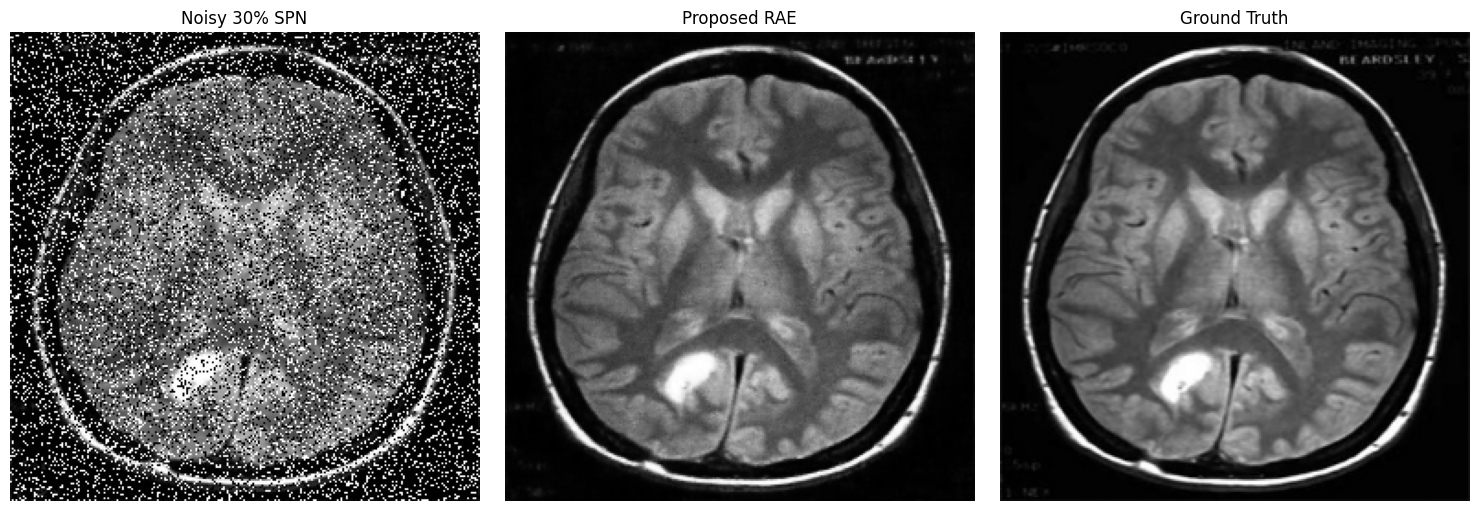

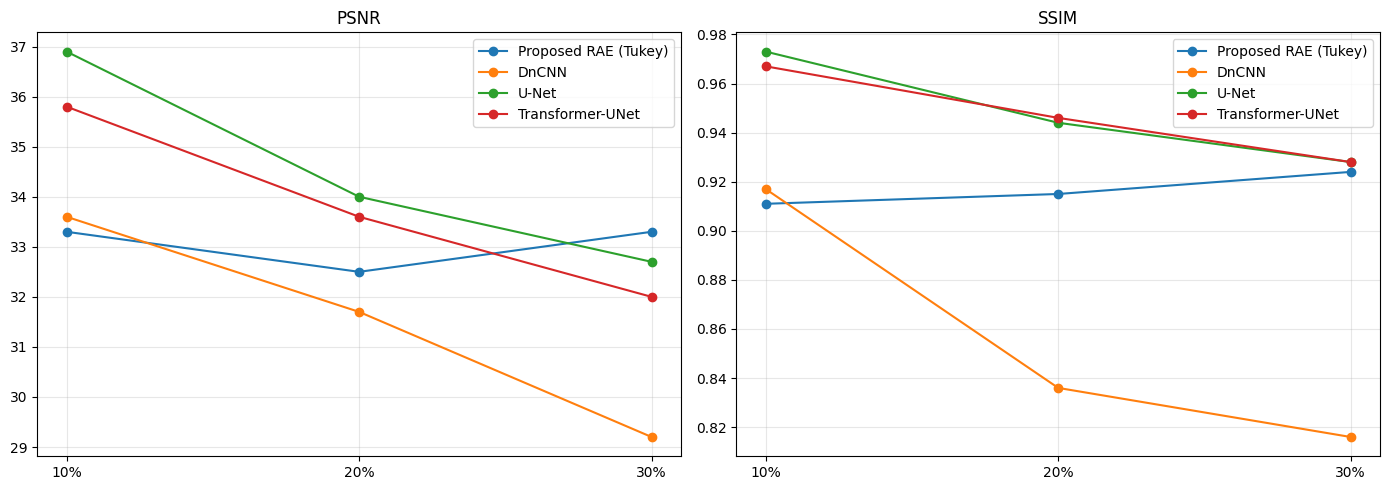

🎉 All done! Results saved in /kaggle/working/0601/


In [10]:
# ==========================================
# CELL 9: VISUALIZATIONS
# ==========================================
# Sample restoration
idx = 0
noisy = test_noisy_dict['spn_30'][idx]
pred  = model_rae_30.predict(noisy[np.newaxis,...], verbose=0)[0]

plt.figure(figsize=(15,5))
plt.subplot(1,3,1); plt.imshow(noisy.squeeze(), cmap='gray'); plt.title('Noisy 30% SPN'); plt.axis('off')
plt.subplot(1,3,2); plt.imshow(pred.squeeze(), cmap='gray');  plt.title('Proposed RAE'); plt.axis('off')
plt.subplot(1,3,3); plt.imshow(X_test[idx].squeeze(), cmap='gray'); plt.title('Ground Truth'); plt.axis('off')
plt.tight_layout()
plt.savefig('/kaggle/working/0601/sample_restoration.png', dpi=300)
plt.show()

# Performance across noise levels
df_spn = df_results[~df_results['Noise'].isin(['GAUSSIAN','RICIAN','POISSON'])]

fig, axes = plt.subplots(1, 2, figsize=(14,5))
for ax, metric in zip(axes, ['PSNR', 'SSIM']):
    for model in ['Proposed RAE (Tukey)', 'DnCNN', 'U-Net', 'Transformer-UNet']:
        vals = []
        for n in ['10% SPN', '20% SPN', '30% SPN']:
            row = df_spn[(df_spn['Model']==model) & (df_spn['Noise']==n)]
            vals.append(float(row[metric].values[0].split('±')[0]) if not row.empty else 0)
        ax.plot(['10%','20%','30%'], vals, marker='o', label=model)
    ax.set_title(metric)
    ax.legend()
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/kaggle/working/0601/performance_curves.png', dpi=300)
plt.show()

print("🎉 All done! Results saved in /kaggle/working/0601/")

In [11]:
# ==========================================
# CELL 10: FINAL SUMMARY
# ==========================================
print("\n" + "="*70)
print("✅ EXPERIMENT COMPLETED SUCCESSFULLY")
print("="*70)
print("\nGenerated Files:")
print("  • Full_Results.csv")
print("  • ablation_architecture.csv")
print("  • ablation_tukey_c.csv")
print("  • training_curves_rae_30.png")
print("  • sample_restoration.png")
print("  • performance_curves.png")
print("  • best_rae_model.keras")
print("\nKey Improvements Included:")
print("  ✓ Proper Wilcoxon statistical tests")
print("  ✓ Quantitative architecture ablation")
print("  ✓ Tukey constant c ablation")
print("  ✓ Transformer-UNet baseline")
print("  ✓ Generalization to Gaussian/Rician/Poisson")
print("  ✓ Computational efficiency")
print("  ✓ Full reproducibility settings")
print("="*70)


✅ EXPERIMENT COMPLETED SUCCESSFULLY

Generated Files:
  • Full_Results.csv
  • ablation_architecture.csv
  • ablation_tukey_c.csv
  • training_curves_rae_30.png
  • sample_restoration.png
  • performance_curves.png
  • best_rae_model.keras

Key Improvements Included:
  ✓ Proper Wilcoxon statistical tests
  ✓ Quantitative architecture ablation
  ✓ Tukey constant c ablation
  ✓ Transformer-UNet baseline
  ✓ Generalization to Gaussian/Rician/Poisson
  ✓ Computational efficiency
  ✓ Full reproducibility settings
